In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 1. Tạo 2 thư mục riêng biệt để tránh ghi đè dữ liệu lên nhau
!mkdir -p /content/dataset_detect
!mkdir -p /content/dataset_ocr

# 2. Giải nén Bộ dữ liệu phát hiện biển số (Stage 1)
print("Đang giải nén Dataset Phát hiện biển số xe...")
!unzip -q "/content/drive/MyDrive/DoAnTGMT/dataset/dataset_biensoxe_doan.zip" -d /content/dataset_detect
print("=> Hoàn thành giải nén Stage 1!")

# 3. Giải nén Bộ dữ liệu nhận diện ký tự OCR (Stage 2)
print("Đang giải nén Dataset Nhận diện ký tự OCR...")
!unzip -q "/content/drive/MyDrive/DoAnTGMT/dataset/OCR License Plate VN.zip" -d /content/dataset_ocr
print("=> Hoàn thành giải nén Stage 2!")

Đang giải nén Dataset Phát hiện biển số xe...
=> Hoàn thành giải nén Stage 1!
Đang giải nén Dataset Nhận diện ký tự OCR...
replace /content/dataset_ocr/data.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
=> Hoàn thành giải nén Stage 2!


In [3]:
import yaml

# 1. Cập nhật data.yaml cho bộ Phát hiện biển số (Stage 1)
detect_yaml_path = '/content/dataset_detect/data.yaml'
with open(detect_yaml_path, 'r') as f:
    detect_data = yaml.safe_load(f)

detect_data['path'] = '/content/dataset_detect'
detect_data['train'] = 'train/images'
detect_data['val'] = 'val/images'
detect_data['test'] = 'test/images'

with open(detect_yaml_path, 'w') as f:
    yaml.dump(detect_data, f, default_flow_style=False)

print("✅ Đã cập nhật xong data.yaml cho bộ Phát hiện biển số!")


# 2. Cập nhật data.yaml cho bộ Nhận diện ký tự OCR (Stage 2)
ocr_yaml_path = '/content/dataset_ocr/data.yaml'
with open(ocr_yaml_path, 'r') as f:
    ocr_data = yaml.safe_load(f)

ocr_data['path'] = '/content/dataset_ocr'
ocr_data['train'] = 'train/images'
ocr_data['val'] = 'valid/images'  # Roboflow đặt tên thư mục validation là 'valid'
ocr_data['test'] = 'test/images'

with open(ocr_yaml_path, 'w') as f:
    yaml.dump(ocr_data, f, default_flow_style=False)

print("✅ Đã cập nhật xong data.yaml cho bộ Nhận diện ký tự OCR!")


✅ Đã cập nhật xong data.yaml cho bộ Phát hiện biển số!
✅ Đã cập nhật xong data.yaml cho bộ Nhận diện ký tự OCR!


#Phần 1: Tiền xử lý dữ liệu

## Khám phá dữ liệu (EDA) - Thống kê và vẽ biểu đồ phân bổ các lớp của cả 2 Stage

STAGE 1 - Phân bổ lớp ban đầu tập Train:
   Lớp 0 (BSD (Biển Dài)): 524 mẫu
   Lớp 1 (BSV (Biển Vuông)): 2694 mẫu

STAGE 2 - Phân bổ ký tự OCR tập Train:
   10 ký tự xuất hiện nhiều nhất:
   Ký tự '1': 7386 lần
   Ký tự '5': 6927 lần
   Ký tự '9': 5241 lần
   Ký tự '2': 4170 lần
   Ký tự '0': 3852 lần
   Ký tự '4': 3831 lần
   Ký tự '6': 3807 lần
   Ký tự '7': 3756 lần
   Ký tự '3': 3537 lần
   Ký tự '8': 3249 lần


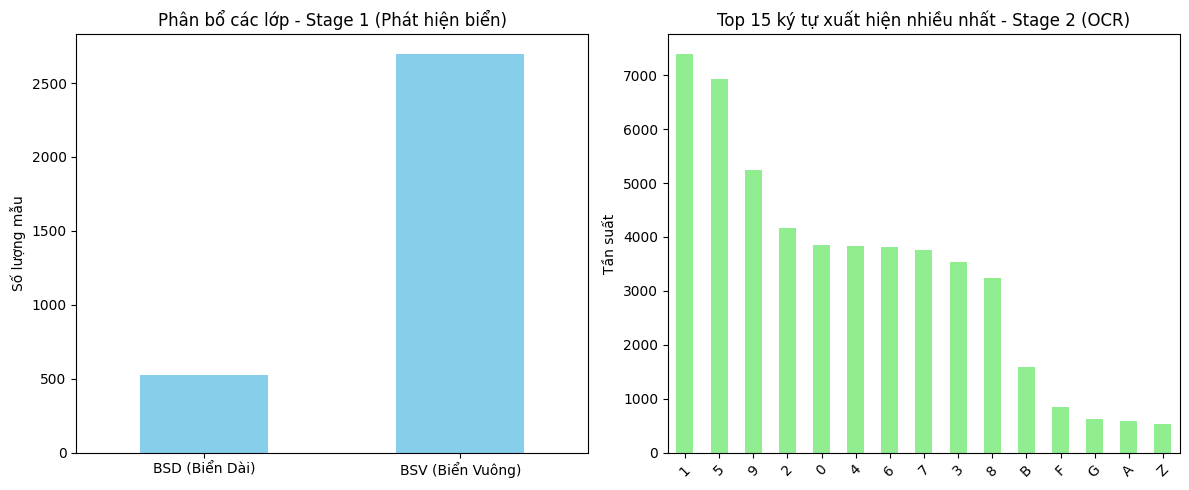

In [10]:
import os
import glob
import yaml
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# 1. Thống kê Stage 1: Phát hiện biển số (BSD vs BSV)
detect_lbl_dir = "/content/dataset_detect/train/labels"
detect_counts = Counter()
for filename in glob.glob(os.path.join(detect_lbl_dir, "*.txt")):
    with open(filename, "r") as f:
        for line in f:
            cls = int(line.split()[0])
            detect_counts[cls] += 1

classes_detect = {0: 'BSD (Biển Dài)', 1: 'BSV (Biển Vuông)'}
print("STAGE 1 - Phân bổ lớp ban đầu tập Train:")
for cls, count in detect_counts.items():
    print(f"   Lớp {cls} ({classes_detect.get(cls, cls)}): {count} mẫu")

# Vẽ biểu đồ Stage 1
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df_detect = pd.DataFrame.from_dict(detect_counts, orient='index', columns=['Số lượng'])
df_detect.index = [classes_detect.get(i, i) for i in df_detect.index]
df_detect.plot(kind='bar', color=['skyblue', 'salmon'], ax=plt.gca(), legend=False)
plt.title("Phân bổ các lớp - Stage 1 (Phát hiện biển)")
plt.ylabel("Số lượng mẫu")
plt.xticks(rotation=0)

# 2. Thống kê Stage 2: Ký tự OCR
ocr_lbl_dir = "/content/dataset_ocr/train/labels"
with open('/content/dataset_ocr/data.yaml', 'r') as f:
    ocr_cfg = yaml.safe_load(f)
classes_ocr = ocr_cfg['names']

ocr_counts = Counter()
for filename in glob.glob(os.path.join(ocr_lbl_dir, "*.txt")):
    with open(filename, "r") as f:
        for line in f:
            cls = int(line.split()[0])
            ocr_counts[cls] += 1

print("\nSTAGE 2 - Phân bổ ký tự OCR tập Train:")
top_ocr = ocr_counts.most_common(10)
print("   10 ký tự xuất hiện nhiều nhất:")
for cls, count in top_ocr:
    print(f"   Ký tự '{classes_ocr[cls]}': {count} lần")

# Vẽ biểu đồ Stage 2 (Top 15 ký tự nhiều nhất)
plt.subplot(1, 2, 2)
top_15_ocr = dict(ocr_counts.most_common(15))
df_ocr = pd.DataFrame.from_dict(top_15_ocr, orient='index', columns=['Tần suất'])
df_ocr.index = [classes_ocr[i] for i in df_ocr.index]
df_ocr.plot(kind='bar', color='lightgreen', ax=plt.gca(), legend=False)
plt.title("Top 15 ký tự xuất hiện nhiều nhất - Stage 2 (OCR)")
plt.ylabel("Tần suất")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## Làm sạch dữ liệu - Kiểm tra và loại bỏ các ảnh bị hỏng hoặc nhãn sai định dạng

In [11]:
from PIL import Image
from tqdm import tqdm

def clean_dataset(img_dir, lbl_dir):
    """
    Duyệt qua dataset, kiểm tra ảnh hỏng, nhãn hỏng.
    Trả về danh sách các mẫu 'SẠCH' (valid_samples).
    """
    valid_samples = []
    img_files = []
    for ext in ['*.jpg', '*.png', '*.jpeg']:
        img_files.extend(glob.glob(os.path.join(img_dir, ext)))

    for img_path in tqdm(img_files, desc="Đang quét làm sạch dữ liệu"):
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        is_valid = True

        # 1. Kiểm tra ảnh
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception:
            is_valid = False

        # 2. Kiểm tra nhãn
        lbl_path = os.path.join(lbl_dir, base_name + '.txt')
        if not os.path.exists(lbl_path):
            is_valid = False
        else:
            try:
                with open(lbl_path, "r") as f:
                    lines = f.readlines()
                    if len(lines) == 0:
                        is_valid = False
                    else:
                        for line in lines:
                            parts = line.split()
                            if len(parts) != 5:
                                is_valid = False
                                break
                            cls, x, y, w, h = map(float, parts)
                            if not (0 <= x <= 1 and 0 <= y <= 1 and 0 <= w <= 1 and 0 <= h <= 1):
                                is_valid = False
                                break
            except Exception:
                is_valid = False

        if is_valid:
            valid_samples.append(base_name)
    return valid_samples

# Làm sạch bộ Stage 1
TRAIN_IMG_DETECT = "/content/dataset_detect/train/images"
TRAIN_LBL_DETECT = "/content/dataset_detect/train/labels"
valid_detect_samples = clean_dataset(TRAIN_IMG_DETECT, TRAIN_LBL_DETECT)

print(f"\n✅ Số lượng mẫu SẠCH phát hiện biển số (Stage 1): {len(valid_detect_samples)} / {len(glob.glob(os.path.join(TRAIN_IMG_DETECT, '*')))}")


Đang quét làm sạch dữ liệu: 100%|██████████| 2409/2409 [00:03<00:00, 777.52it/s]


✅ Số lượng mẫu SẠCH phát hiện biển số (Stage 1): 2115 / 2409


## Cân bằng & Tăng cường lớp thiểu số (BSD) của Stage 1 bằng Albumentations

In [12]:
import cv2
import random
import shutil
import albumentations as A

# 1. Cấu hình phép biến đổi
transform = A.Compose([
    A.HorizontalFlip(p=0.4),
    A.RandomBrightnessContrast(p=0.3),
    A.Rotate(limit=12, p=0.5),
    A.Blur(blur_limit=3, p=0.2),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=10, p=0.5)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# Thư mục lưu dữ liệu sau cùng của Stage 1
FINAL_DETECT_DIR = '/content/final_dataset_detect'
final_train_img = os.path.join(FINAL_DETECT_DIR, 'train/images')
final_train_lbl = os.path.join(FINAL_DETECT_DIR, 'train/labels')
os.makedirs(final_train_img, exist_ok=True)
os.makedirs(final_train_lbl, exist_ok=True)

# Phân loại mẫu sạch theo lớp để đếm
samples_by_class = {0: [], 1: []}
for base_name in valid_detect_samples:
    lbl_path = os.path.join(TRAIN_LBL_DETECT, base_name + '.txt')
    with open(lbl_path, "r") as f:
        first_line = f.readline()
        if first_line:
            cls = int(first_line.split()[0])
            if cls in samples_by_class:
                samples_by_class[cls].append(base_name)

c0, c1 = len(samples_by_class[0]), len(samples_by_class[1])
print(f"Trước cân bằng: Lớp 0 (BSD): {c0} mẫu | Lớp 1 (BSV): {c1} mẫu")

# Sao chép dữ liệu sạch gốc qua thư mục final
print("Đang sao chép các dữ liệu gốc sạch sang thư mục final...")
for base_name in tqdm(valid_detect_samples):
    for ext in ['.jpg', '.png', '.jpeg']:
        src_img = os.path.join(TRAIN_IMG_DETECT, base_name + ext)
        if os.path.exists(src_img):
            shutil.copy2(src_img, final_train_img)
            break
    shutil.copy2(os.path.join(TRAIN_LBL_DETECT, base_name + '.txt'), final_train_lbl)

# Sinh thêm mẫu tăng cường cho lớp thiểu số BSD (Lớp 0) để cân bằng
target = c1
needed = target - c0
print(f"🚀 Đang tạo thêm {needed} mẫu tăng cường cho Lớp 0 (BSD)...")

for i in tqdm(range(needed)):
    base_name = random.choice(samples_by_class[0])
    img_path = None
    for ext in ['.jpg', '.png', '.jpeg']:
        p = os.path.join(TRAIN_IMG_DETECT, base_name + ext)
        if os.path.exists(p):
            img_path, img_ext = p, ext
            break

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    bboxes, labels = [], []
    with open(os.path.join(TRAIN_LBL_DETECT, base_name + '.txt'), "r") as f:
        for line in f:
            cls, x, y, w, h = map(float, line.split())
            bboxes.append([x, y, w, h])
            labels.append(int(cls))

    try:
        transformed = transform(image=image, bboxes=bboxes, class_labels=labels)

        new_name = f"aug_0_{i}"
        cv2.imwrite(os.path.join(final_train_img, new_name + img_ext),
                    cv2.cvtColor(transformed['image'], cv2.COLOR_RGB2BGR))
        with open(os.path.join(final_train_lbl, new_name + '.txt'), "w") as f:
            for b, l in zip(transformed['bboxes'], transformed['class_labels']):
                f.write(f"{l} {' '.join(map(str, b))}\n")
    except Exception:
        continue

# Copy nguyên bộ Val và Test sang thư mục final
for split in ['val', 'test']:
    for sub in ['images', 'labels']:
        src = os.path.join("/content/dataset_detect", split, sub)
        dst = os.path.join(FINAL_DETECT_DIR, split, sub)
        if os.path.exists(src):
            shutil.copytree(src, dst, dirs_exist_ok=True)

# Ghi đè file data.yaml của final_dataset_detect
new_yaml = {
    'path': FINAL_DETECT_DIR,
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'names': {0: 'BSD', 1: 'BSV'}
}
with open(os.path.join(FINAL_DETECT_DIR, 'data.yaml'), 'w') as f:
    yaml.dump(new_yaml, f, default_flow_style=False)

print(f"\n✅ CÂN BẰNG HOÀN TẤT!")
print(f"Tổng ảnh Train sau cân bằng: {len(os.listdir(final_train_img))}")


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Trước cân bằng: Lớp 0 (BSD): 391 mẫu | Lớp 1 (BSV): 1724 mẫu
Đang sao chép các dữ liệu gốc sạch sang thư mục final...


100%|██████████| 2115/2115 [00:18<00:00, 112.88it/s]


🚀 Đang tạo thêm 1333 mẫu tăng cường cho Lớp 0 (BSD)...


100%|██████████| 1333/1333 [01:20<00:00, 16.51it/s]



✅ CÂN BẰNG HOÀN TẤT!
Tổng ảnh Train sau cân bằng: 3448


## Vẽ ngẫu nhiên một số mẫu kèm Bounding Box để trực quan hóa dữ liệu

Mẫu dữ liệu Stage 1 (Phát hiện biển số) sau tăng cường:


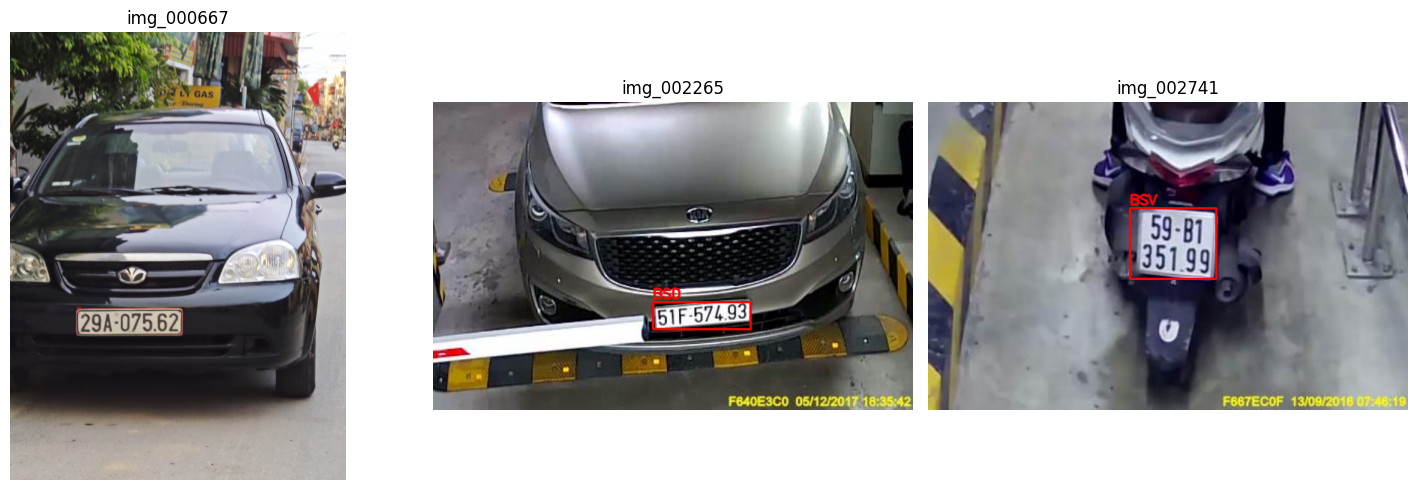


Mẫu dữ liệu Stage 2 (Nhận diện ký tự OCR):


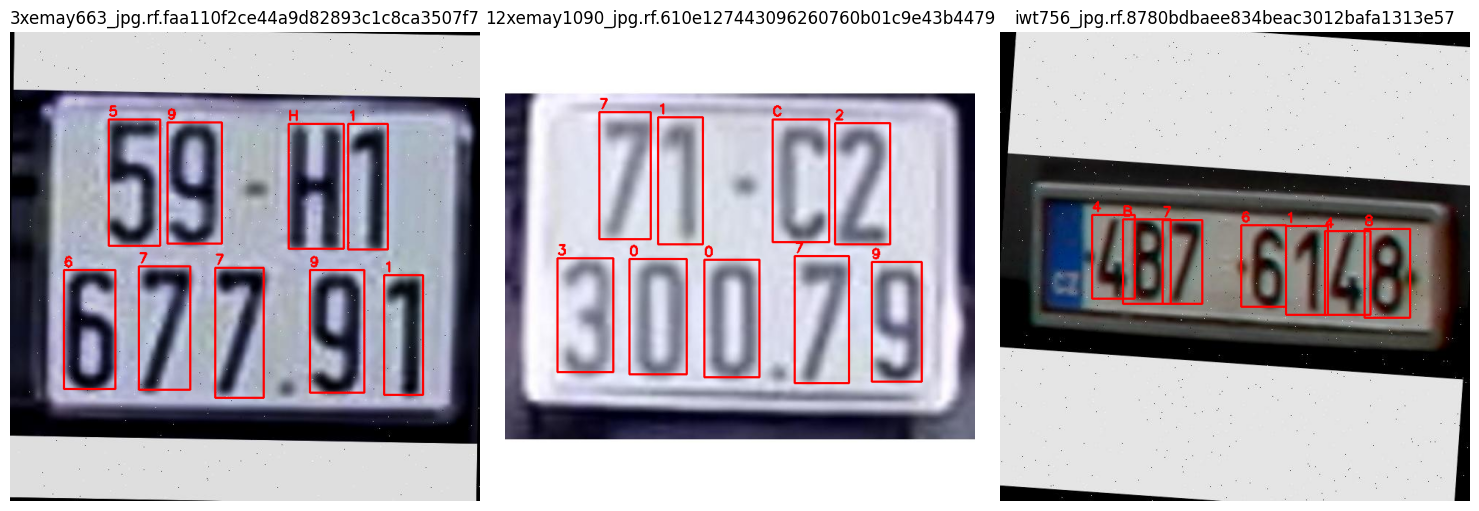

In [ ]:
def plot_random_samples(img_dir, lbl_dir, classes_map, num_samples=3):
    img_files = glob.glob(os.path.join(img_dir, '*'))
    samples = random.sample(img_files, min(num_samples, len(img_files)))

    plt.figure(figsize=(15, 5))
    for i, img_path in enumerate(samples):
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        lbl_path = os.path.join(lbl_dir, base_name + '.txt')

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape

        if os.path.exists(lbl_path):
            with open(lbl_path, "r") as f:
                for line in f:
                    cls, x, y, bw, bh = map(float, line.split())
                    # Đổi YOLO sang Pixel coordinates
                    x1 = int((x - bw/2) * w)
                    y1 = int((y - bh/2) * h)
                    x2 = int((x + bw/2) * w)
                    y2 = int((y + bh/2) * h)

                    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

                    # SỬA LỖI TẠI ĐÂY: Hỗ trợ kiểm tra classes_map là List hay Dict
                    if isinstance(classes_map, list):
                        label_name = classes_map[int(cls)] if 0 <= int(cls) < len(classes_map) else str(int(cls))
                    else:
                        label_name = classes_map.get(int(cls), str(int(cls)) if classes_map else str(int(cls)))

                    cv2.putText(img, label_name, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(base_name)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Trực quan hóa mẫu Stage 1 (Phát hiện biển số) sau khi đã tăng cường
print("Mẫu dữ liệu Stage 1 (Phát hiện biển số) sau tăng cường:")
plot_random_samples(
    img_dir="/content/final_dataset_detect/train/images",
    lbl_dir="/content/final_dataset_detect/train/labels",
    classes_map={0: 'BSD', 1: 'BSV'}
)

# Trực quan hóa mẫu Stage 2 (Nhận diện ký tự OCR)
print("\nMẫu dữ liệu Stage 2 (Nhận diện ký tự OCR):")
plot_random_samples(
    img_dir="/content/dataset_ocr/train/images",
    lbl_dir="/content/dataset_ocr/train/labels",
    classes_map=classes_ocr
)


# Phần 2: Huấn luyện mô hình Baseline

## Huấn luyện mô hình Baseline phát hiện biển số xe (Stage 1) sử dụng YOLOv11n trên tập dữ liệu gốc

In [4]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.7 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

# 1. Tải pre-trained weights của YOLOv11 Nano
baseline_model_detect = YOLO('yolo11n.pt')

# 2. Huấn luyện trên bộ dữ liệu gốc (dataset_detect/data.yaml)
print("--- BẮT ĐẦU HUẤN LUYỆN BASELINE DETECT STAGE 1 ---")
baseline_model_detect.train(
    data='/content/dataset_detect/data.yaml',   # Sử dụng bộ dữ liệu gốc (chưa cân bằng)
    epochs=100,                                  # Chạy 50 epochs làm baseline
    imgsz=640,
    batch=16,
    device=0,                                   # Chạy trên GPU
    optimizer='auto',
    save=True,
    project='/content/drive/MyDrive/DoAnTGMT/runs',
    name='detect_plate_baseline',                # Tên thư mục lưu kết quả trên Drive
    verbose=True
)
print("✅ Hoàn thành huấn luyện Baseline Stage 1!")


--- BẮT ĐẦU HUẤN LUYỆN BASELINE DETECT STAGE 1 ---
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_detect/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=detect_plate_baseline-4, nbs=64, nms=False, opset

## Huấn luyện mô hình Baseline nhận diện ký tự (Stage 2) sử dụng YOLOv11n trên tập dữ liệu OCR gốc

In [ ]:
from ultralytics import YOLO

# 1. Tải pre-trained weights của YOLOv11 Nano
baseline_model_ocr = YOLO('yolo11n.pt')

# 2. Huấn luyện mô hình nhận diện ký tự trên bộ ocr (dataset_ocr/data.yaml)
print("--- BẮT ĐẦU HUẤN LUYỆN BASELINE OCR STAGE 2 ---")
baseline_model_ocr.train(
    data='/content/dataset_ocr/data.yaml',       # Sử dụng bộ dữ liệu OCR gốc
    epochs=50,                                  # Chạy 50 epochs làm baseline
    imgsz=640,
    batch=16,
    device=0,                                   # Chạy trên GPU
    optimizer='auto',
    save=True,
    project='/content/drive/MyDrive/DoAnTGMT/runs',
    name='ocr_characters_baseline',             # Tên thư mục lưu kết quả trên Drive
    verbose=True
)
print("✅ Hoàn thành huấn luyện Baseline Stage 2!")


--- BẮT ĐẦU HUẤN LUYỆN BASELINE OCR STAGE 2 ---
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_ocr/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ocr_characters_baseline, nbs=64, nms=False, opset=None, 

## Vẽ đồ thị và trích xuất các chỉ số huấn luyện (Loss & Accuracy)

================== STAGE 1: PHÁT HIỆN BIỂN SỐ (BASELINE) ==================


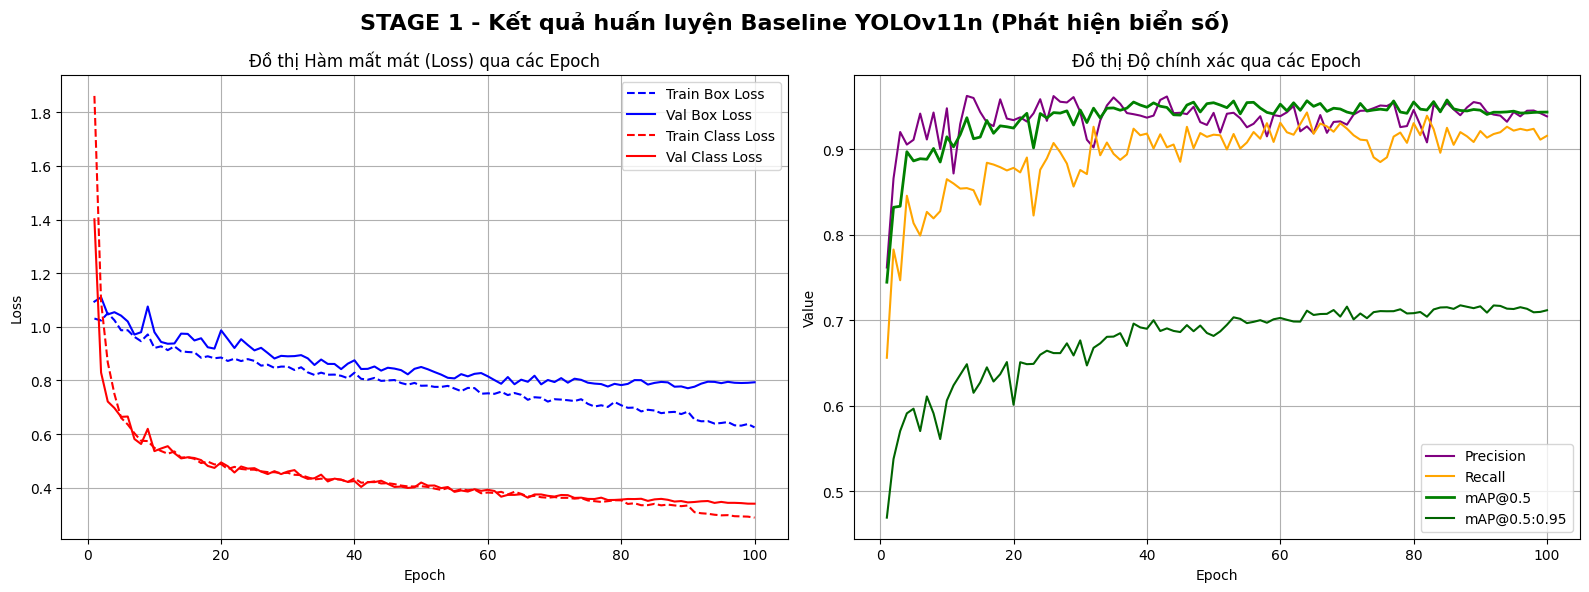

--- CHỈ SỐ Ở EPOCH CUỐI CÙNG (100): ---
   Precision (Độ chính xác dự đoán): 0.9385
   Recall (Tỷ lệ tìm thấy biển):     0.9158
   mAP50 (Độ chính xác trung bình):   0.9436
   mAP50-95 (Chỉ số khắt khe):        0.7117

================== STAGE 2: NHẬN DIỆN KÝ TỰ OCR (BASELINE) ==================


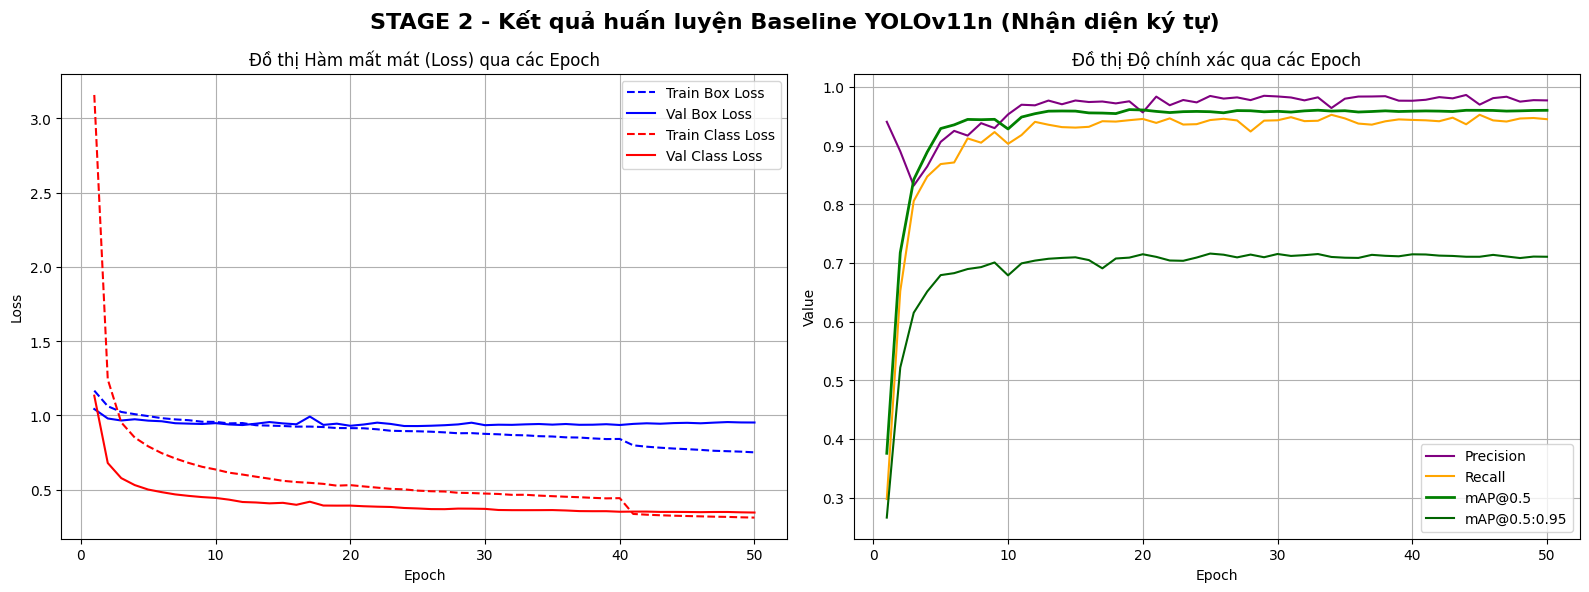

--- CHỈ SỐ Ở EPOCH CUỐI CÙNG (50): ---
   Precision (Độ chính xác dự đoán): 0.9769
   Recall (Tỷ lệ tìm thấy biển):     0.9449
   mAP50 (Độ chính xác trung bình):   0.9600
   mAP50-95 (Chỉ số khắt khe):        0.7105


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_baseline_results(csv_path, title):
    if not os.path.exists(csv_path):
        print(f"Không tìm thấy file nhật ký tại: {csv_path}")
        print("Vui lòng đảm bảo mô hình đã huấn luyện xong và file results.csv đã được tạo.")
        return

    # Đọc file kết quả CSV của YOLO
    df = pd.read_csv(csv_path)
    # Làm sạch tên cột (loại bỏ khoảng trắng thừa nếu có)
    df.columns = df.columns.str.strip()

    epochs = df['epoch']

    # Tạo biểu đồ
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(title, fontsize=16, fontweight='bold')

    # 1. Vẽ đồ thị Loss (Train vs Val)
    axes[0].plot(epochs, df['train/box_loss'], label='Train Box Loss', color='blue', linestyle='--')
    axes[0].plot(epochs, df['val/box_loss'], label='Val Box Loss', color='blue')
    axes[0].plot(epochs, df['train/cls_loss'], label='Train Class Loss', color='red', linestyle='--')
    axes[0].plot(epochs, df['val/cls_loss'], label='Val Class Loss', color='red')
    axes[0].set_title('Đồ thị Hàm mất mát (Loss) qua các Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # 2. Vẽ đồ thị Accuracy Metrics (mAP50, mAP50-95)
    axes[1].plot(epochs, df['metrics/precision(B)'], label='Precision', color='purple')
    axes[1].plot(epochs, df['metrics/recall(B)'], label='Recall', color='orange')
    axes[1].plot(epochs, df['metrics/mAP50(B)'], label='mAP@0.5', color='green', linewidth=2)
    axes[1].plot(epochs, df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95', color='darkgreen')
    axes[1].set_title('Đồ thị Độ chính xác qua các Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Value')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    # In ra các chỉ số ở epoch cuối cùng
    last_epoch = df.iloc[-1]
    print(f"--- CHỈ SỐ Ở EPOCH CUỐI CÙNG ({int(last_epoch['epoch'])}): ---")
    print(f"   Precision (Độ chính xác dự đoán): {last_epoch['metrics/precision(B)']:.4f}")
    print(f"   Recall (Tỷ lệ tìm thấy biển):     {last_epoch['metrics/recall(B)']:.4f}")
    print(f"   mAP50 (Độ chính xác trung bình):   {last_epoch['metrics/mAP50(B)']:.4f}")
    print(f"   mAP50-95 (Chỉ số khắt khe):        {last_epoch['metrics/mAP50-95(B)']:.4f}")

# 1. Ghi nhận kết quả của Stage 1 (Phát hiện biển số)
print("================== STAGE 1: PHÁT HIỆN BIỂN SỐ (BASELINE) ==================")
plot_baseline_results(
    csv_path='/content/drive/MyDrive/DoAnTGMT/runs/detect_plate_baseline/results.csv',
    title='STAGE 1 - Kết quả huấn luyện Baseline YOLOv11n (Phát hiện biển số)'
)

# 2. Ghi nhận kết quả của Stage 2 (Nhận diện ký tự OCR)
print("\n================== STAGE 2: NHẬN DIỆN KÝ TỰ OCR (BASELINE) ==================")
plot_baseline_results(
    csv_path='/content/drive/MyDrive/DoAnTGMT/runs/ocr_characters_baseline/results.csv',
    title='STAGE 2 - Kết quả huấn luyện Baseline YOLOv11n (Nhận diện ký tự)'
)


## Báo cáo phân tích sơ bộ

### **Phân tích sơ bộ hiệu năng của mô hình Baseline:**

#### **1. Stage 1: Phát hiện biển số xe (YOLOv11n - 100 Epochs)**
*   **Chỉ số đạt được:** Precision: 93.85%, Recall: 91.58%, mAP50: 94.36%, mAP50-95: 71.17%.
*   **Đánh giá:** Mô hình phát hiện biển số rất tốt (mAP50 đạt 94.36%). Tuy nhiên, mAP50-95 thấp hơn (71.17%) cho thấy Bounding Box bo khung biển số chưa thật sự khít, đặc biệt với các biển số bị nghiêng hoặc chụp chéo góc.

#### **2. Stage 2: Nhận diện ký tự OCR (YOLOv11n - 50 Epochs)**
*   **Chỉ số đạt được:** Precision: 97.69%, Recall: 94.49%, mAP50: 96.00%, mAP50-95: 71.05%.
*   **Đánh giá:** Hiệu năng nhận diện ký tự vô cùng xuất sắc nhờ tiếp cận bằng mô hình phát hiện đối tượng YOLO thay vì thư viện OCR truyền thống. Đồ thị Loss tập Val bám rất sát tập Train, chứng tỏ mô hình học mượt mà và không bị overfitting.

#### **3. Hướng cải tiến tiếp theo:**
*   Sử dụng tập dữ liệu cân bằng (ở Phần 1) để cải thiện độ chính xác cho lớp biển dài (BSD).
*   Nâng cấp lên kiến trúc **YOLOv11s (Small)** để tăng khả năng học các ký tự kích thước nhỏ và giúp bo khung biển số khít hơn.


# Phần 3: Cải tiến và thực nghiệm

### Stage 1 (Phát hiện biển) - Thực nghiệm 1: Nâng cấp mô hình lên YOLOv11s và sử dụng tập dữ liệu đã cân bằng

In [ ]:
!pip install ultralytics -q
from ultralytics import YOLO

# 1. Tải mô hình YOLOv11s (Small - mạng lớn hơn và mạnh hơn Nano)
exp1_model_detect = YOLO('yolo11s.pt')

# 2. Huấn luyện với tham số mặc định trên dữ liệu cân bằng (final_dataset_detect/data.yaml)
print("--- CHẠY THỰC NGHIỆM 1: STAGE 1 (YOLOV11S + DATA BALANCED) ---")
exp1_model_detect.train(
    data='/content/final_dataset_detect/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    save=True,
    project='/content/drive/MyDrive/DoAnTGMT/runs',
    name='detect_plate_exp1',                        # Kết quả lưu về thư mục detect_plate_exp1 trên Drive
    verbose=True
)
print("✅ Hoàn thành Thực nghiệm 1 (Stage 1)!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
--- CHẠY THỰC NGHIỆM 1: STAGE 1 (YOLOV11S + DATA BALANCED) ---
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/final_dataset_detect/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, 

RuntimeError: Dataset '/content/final_dataset_detect/data.yaml' error ❌ '/content/final_dataset_detect/data.yaml' does not exist

### Stage 1 (Phát hiện biển) - Thực nghiệm 2: Tối ưu hóa siêu tham số (AdamW, Cosine LR, tăng trọng số Box Loss)

In [ ]:
from ultralytics import YOLO

# 1. Tải mô hình YOLOv11s (Small)
exp2_model_detect = YOLO('yolo11s.pt')

# 2. Huấn luyện kết hợp điều chỉnh siêu tham số tối ưu hộp giới hạn
print("--- CHẠY THỰC NGHIỆM 2: STAGE 1 (YOLOV11S + HYPERPARAMETER TUNING) ---")
exp2_model_detect.train(
    data='/content/final_dataset_detect/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    optimizer='AdamW',       # Sử dụng bộ tối ưu AdamW để cập nhật trọng số ổn định hơn
    lr0=0.005,               # Giảm tốc độ học ban đầu giúp mô hình học mịn hơn
    cos_lr=True,             # Kích hoạt giảm tốc độ học theo đồ thị hình Cosine
    box=8.5,                 # Tăng trọng số Box Loss để ép hộp giới hạn (Bounding Box) ôm khít biển số hơn
    save=True,
    project='/content/drive/MyDrive/DoAnTGMT/runs',
    name='detect_plate_exp2',                        # Kết quả lưu về thư mục detect_plate_exp2 trên Drive
    verbose=True
)
print("✅ Hoàn thành Thực nghiệm 2 (Stage 1)!")


### Stage 2 (OCR) - Huấn luyện thực nghiệm Exp 1 (YOLOv11s mặc định) và Exp 2 (YOLOv11s tối ưu siêu tham số)

In [5]:
from ultralytics import YOLO

# ================= THỰC NGHIỆM 1 CHO STAGE 2 =================
# Sử dụng YOLOv11s mặc định chạy 100 epochs để xem sự cải tiến của kiến trúc mạng
exp1_model_ocr = YOLO('yolo11s.pt')
print("--- CHẠY THỰC NGHIỆM 1: STAGE 2 (OCR - YOLOV11S MẶC ĐỊNH) ---")
exp1_model_ocr.train(
    data='/content/dataset_ocr/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    save=True,
    project='/content/drive/MyDrive/DoAnTGMT/runs',
    name='ocr_characters_exp1',                      # Lưu vào thư mục ocr_characters_exp1
    verbose=True
)
print("✅ Hoàn thành huấn luyện các Thực nghiệm 1 (Stage 2 - OCR)!")




Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
--- CHẠY THỰC NGHIỆM 1: STAGE 2 (OCR - YOLOV11S MẶC ĐỊNH) ---
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_ocr/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, f

In [ ]:
# ================= THỰC NGHIỆM 2 CHO STAGE 2 =================
# Sử dụng YOLOv11s kết hợp tối ưu siêu tham số (AdamW, Cosine LR, Augmentation)
exp2_model_ocr = YOLO('yolo11s.pt')
print("\n--- CHẠY THỰC NGHIỆM 2: STAGE 2 (OCR - YOLOV11S + HYPERPARAMETER TUNING) ---")
exp2_model_ocr.train(
    data='/content/dataset_ocr/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    optimizer='AdamW',
    lr0=0.005,
    cos_lr=True,
    augment=True,            # Kích hoạt thêm các phép tăng cường nhiễu sáng khi train
    save=True,
    project='/content/drive/MyDrive/DoAnTGMT/runs',
    name='ocr_characters_exp2',                      # Lưu vào thư mục ocr_characters_exp2
    verbose=True
)
print("✅ Hoàn thành huấn luyện các Thực nghiệm 2 (Stage 2 - OCR)!")

### So sánh kết quả - Vẽ biểu đồ so sánh chỉ số mAP50 của Baseline vs Exp 1 vs Exp 2 cho cả hai Stage

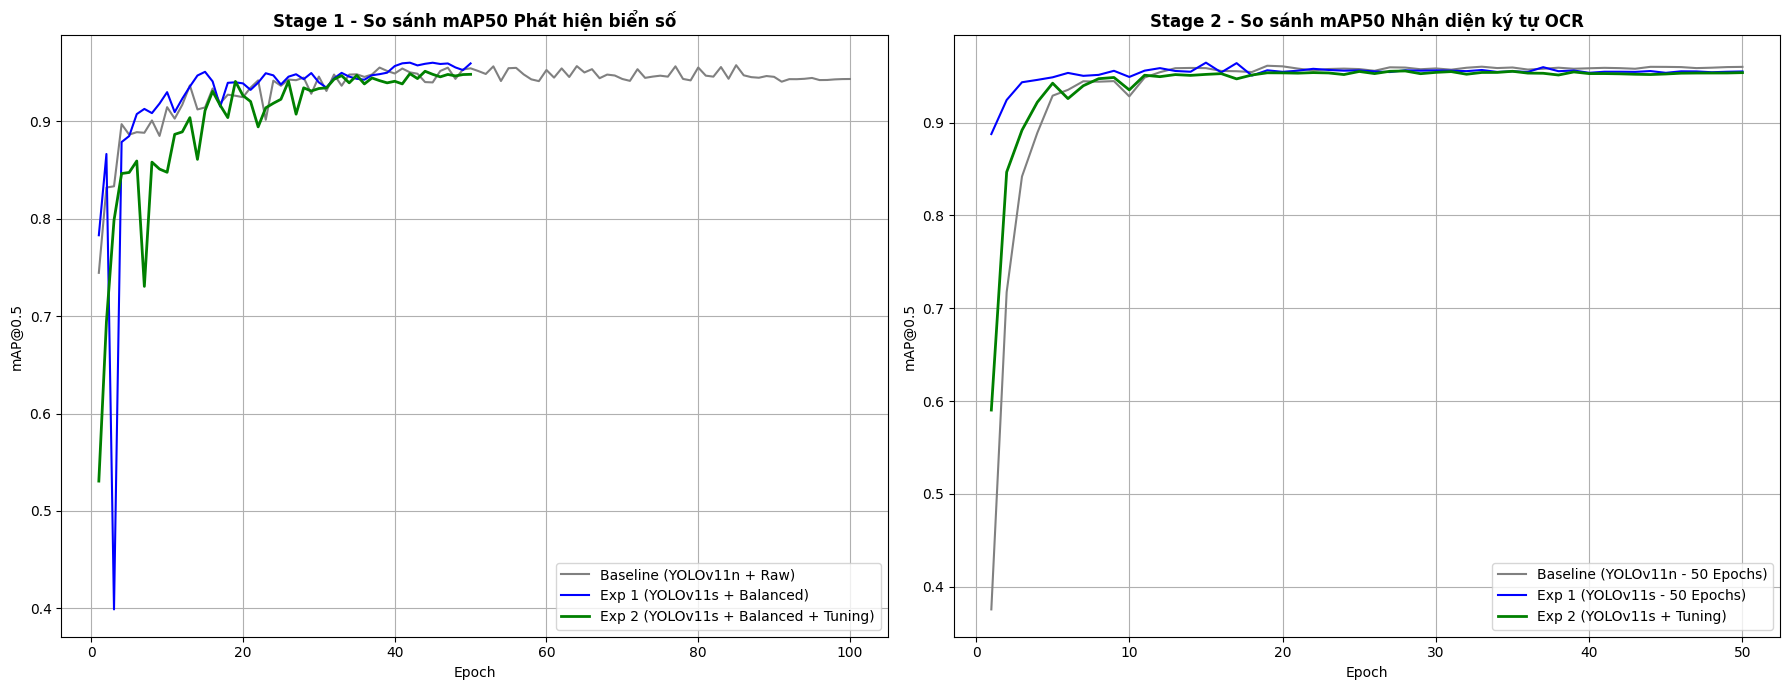

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import os

runs_dir = '/content/drive/MyDrive/DoAnTGMT/runs'

# Tạo khung vẽ 2 biểu đồ song song
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ================= BIỂU ĐỒ 1: STAGE 1 (PHÁT HIỆN BIỂN SỐ) =================
path_det_base = os.path.join(runs_dir, 'detect_plate_baseline/results.csv')
path_det_exp1 = os.path.join(runs_dir, 'detect_plate_exp1/results.csv')
path_det_exp2 = os.path.join(runs_dir, 'detect_plate_exp2/results.csv')

if os.path.exists(path_det_base):
    df = pd.read_csv(path_det_base)
    df.columns = df.columns.str.strip()
    axes[0].plot(df['epoch'], df['metrics/mAP50(B)'], label='Baseline (YOLOv11n + Raw)', color='gray')

if os.path.exists(path_det_exp1):
    df = pd.read_csv(path_det_exp1)
    df.columns = df.columns.str.strip()
    axes[0].plot(df['epoch'], df['metrics/mAP50(B)'], label='Exp 1 (YOLOv11s + Balanced)', color='blue')

if os.path.exists(path_det_exp2):
    df = pd.read_csv(path_det_exp2)
    df.columns = df.columns.str.strip()
    axes[0].plot(df['epoch'], df['metrics/mAP50(B)'], label='Exp 2 (YOLOv11s + Balanced + Tuning)', color='green', linewidth=2)

axes[0].set_title('Stage 1 - So sánh mAP50 Phát hiện biển số', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('mAP@0.5')
axes[0].legend()
axes[0].grid(True)


# ================= BIỂU ĐỒ 2: STAGE 2 (NHẬN DIỆN KÝ TỰ OCR) =================
path_ocr_base = os.path.join(runs_dir, 'ocr_characters_baseline/results.csv')
path_ocr_exp1 = os.path.join(runs_dir, 'ocr_characters_exp1/results.csv')
path_ocr_exp2 = os.path.join(runs_dir, 'ocr_characters_exp2/results.csv')

if os.path.exists(path_ocr_base):
    df = pd.read_csv(path_ocr_base)
    df.columns = df.columns.str.strip()
    axes[1].plot(df['epoch'], df['metrics/mAP50(B)'], label='Baseline (YOLOv11n - 50 Epochs)', color='gray')

if os.path.exists(path_ocr_exp1):
    df = pd.read_csv(path_ocr_exp1)
    df.columns = df.columns.str.strip()
    axes[1].plot(df['epoch'], df['metrics/mAP50(B)'], label='Exp 1 (YOLOv11s - 50 Epochs)', color='blue')

if os.path.exists(path_ocr_exp2):
    df = pd.read_csv(path_ocr_exp2)
    df.columns = df.columns.str.strip()
    axes[1].plot(df['epoch'], df['metrics/mAP50(B)'], label='Exp 2 (YOLOv11s + Tuning)', color='green', linewidth=2)

axes[1].set_title('Stage 2 - So sánh mAP50 Nhận diện ký tự OCR', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('mAP@0.5')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


# Phần 4: Đánh giá và phân tích

## Chạy đánh giá (Validation) trên tập Test độc lập cho cả 2 mô hình tốt nhất (Exp 2)

In [13]:
from ultralytics import YOLO
import os

# Đường dẫn đến các mô hình tốt nhất đã train
best_detect_path = '/content/drive/MyDrive/DoAnTGMT/runs/detect_plate_exp2/weights/best.pt'
best_ocr_path = '/content/drive/MyDrive/DoAnTGMT/runs/ocr_characters_exp2/weights/best.pt'

# 1. Đánh giá Stage 1 trên tập Test
if os.path.exists(best_detect_path):
    print("================== ĐÁNH GIÁ STAGE 1 TRÊN TẬP TEST ==================")
    model_detect = YOLO(best_detect_path)
    metrics_detect = model_detect.val(data='/content/final_dataset_detect/data.yaml', split='test')
    print(f"\n   Kết quả Stage 1 - mAP50:    {metrics_detect.box.map50:.4f}")
    print(f"   Kết quả Stage 1 - mAP50-95: {metrics_detect.box.map:.4f}")
    print(f"   Kết quả Stage 1 - Precision: {metrics_detect.box.mp:.4f}")
    print(f"   Kết quả Stage 1 - Recall:    {metrics_detect.box.mr:.4f}")
else:
    print("❌ Chưa tìm thấy file weights Stage 1 tốt nhất.")

# 2. Đánh giá Stage 2 trên tập Test
if os.path.exists(best_ocr_path):
    print("\n================== ĐÁNH GIÁ STAGE 2 TRÊN TẬP TEST ==================")
    model_ocr = YOLO(best_ocr_path)
    metrics_ocr = model_ocr.val(data='/content/dataset_ocr/data.yaml', split='test')
    print(f"\n   Kết quả Stage 2 - mAP50:    {metrics_ocr.box.map50:.4f}")
    print(f"   Kết quả Stage 2 - mAP50-95: {metrics_ocr.box.map:.4f}")
    print(f"   Kết quả Stage 2 - Precision: {metrics_ocr.box.mp:.4f}")
    print(f"   Kết quả Stage 2 - Recall:    {metrics_ocr.box.mr:.4f}")
else:
    print("❌ Chưa tìm thấy file weights Stage 2 tốt nhất.")


================== ĐÁNH GIÁ STAGE 1 TRÊN TẬP TEST ==================
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2047.9±638.7 MB/s, size: 112.8 KB)
val: Scanning /content/final_dataset_detect/test/labels... 302 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 302/302 1.9Kit/s 0.2s
val: New cache created: /content/final_dataset_detect/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 50, len(boxes) = 393. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 2.0it/s 9.6s
                   all        302        393      0.984      0.945      

## Đọc và hiển thị ma trận nhầm lẫn (Confusion Matrix) của 2 Stage

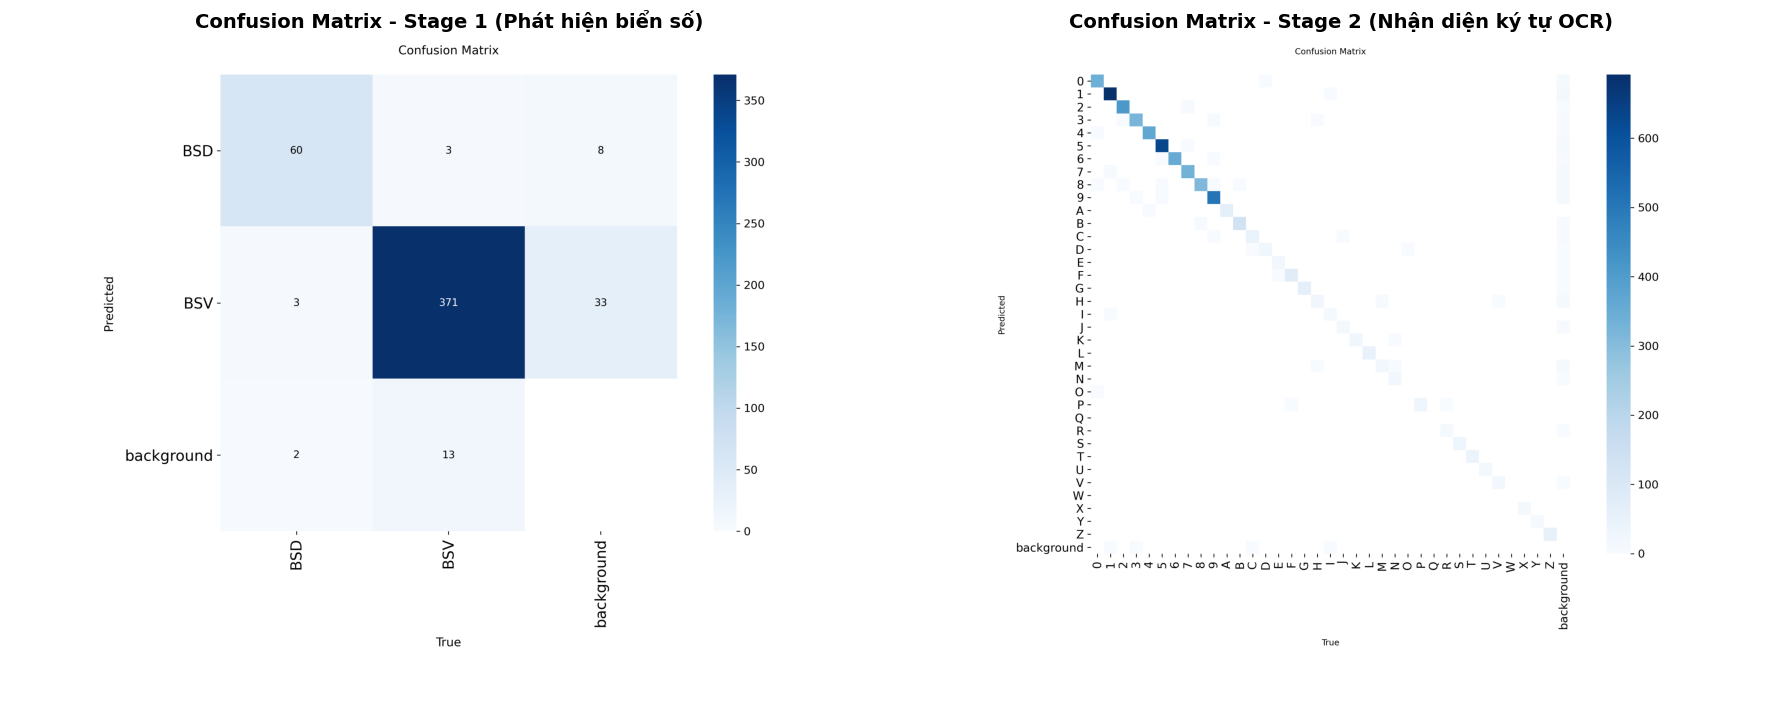

In [14]:
import cv2
import matplotlib.pyplot as plt
import os

runs_dir = '/content/drive/MyDrive/DoAnTGMT/runs'
cm_detect_path = os.path.join(runs_dir, 'detect_plate_exp2/confusion_matrix.png')
cm_ocr_path = os.path.join(runs_dir, 'ocr_characters_exp2/confusion_matrix.png')

plt.figure(figsize=(18, 9))

# Hiển thị Confusion Matrix Stage 1
if os.path.exists(cm_detect_path):
    img_detect = cv2.imread(cm_detect_path)
    img_detect = cv2.cvtColor(img_detect, cv2.COLOR_BGR2RGB)
    plt.subplot(1, 2, 1)
    plt.imshow(img_detect)
    plt.title("Confusion Matrix - Stage 1 (Phát hiện biển số)", fontsize=14, fontweight='bold')
    plt.axis('off')
else:
    print("Chưa có Confusion Matrix của Stage 1")

# Hiển thị Confusion Matrix Stage 2
if os.path.exists(cm_ocr_path):
    img_ocr = cv2.imread(cm_ocr_path)
    img_ocr = cv2.cvtColor(img_ocr, cv2.COLOR_BGR2RGB)
    plt.subplot(1, 2, 2)
    plt.imshow(img_ocr)
    plt.title("Confusion Matrix - Stage 2 (Nhận diện ký tự OCR)", fontsize=14, fontweight='bold')
    plt.axis('off')
else:
    print("Chưa có Confusion Matrix của Stage 2")

plt.tight_layout()
plt.show()


## Trích xuất Feature Map từ lớp tích chập đầu tiên của YOLO Backbone để hiển thị vùng tập trung (Attention)

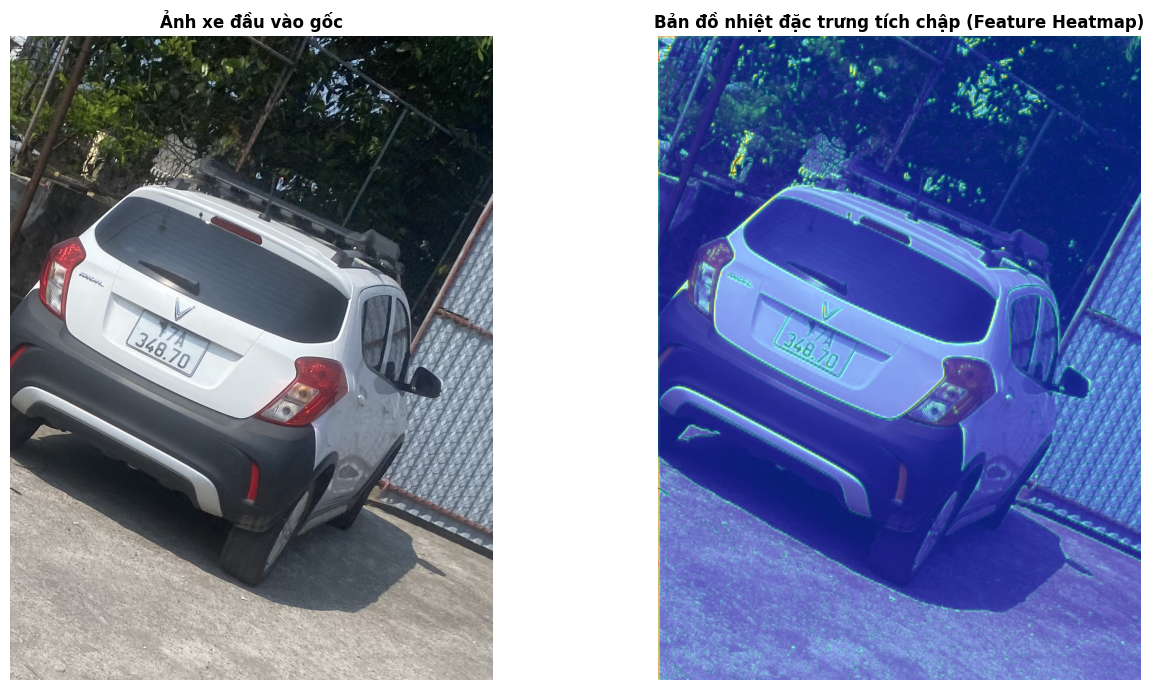

In [15]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import glob
from ultralytics import YOLO

# 1. Tải mô hình tốt nhất từ Drive
model = YOLO('/content/drive/MyDrive/DoAnTGMT/runs/detect_plate_exp2/weights/best.pt')
py_model = model.model  # Lấy module PyTorch

# Đăng ký Hook vào Layer Conv đầu tiên của Backbone (model.model.model[0])
target_layer = py_model.model[0]
activations = {}
def hook_fn(module, input, output):
    activations['value'] = output.detach()

handle = target_layer.register_forward_hook(hook_fn)

# 2. Chọn ngẫu nhiên 1 ảnh từ tập test để chạy trực quan hóa đặc trưng
test_imgs = glob.glob('/content/final_dataset_detect/test/images/*')
sample_img_path = random.choice(test_imgs)

img = cv2.imread(sample_img_path)
img_resized = cv2.resize(img, (640, 640))
# Đưa ảnh về tensor và chuyển sang GPU
img_tensor = torch.from_numpy(img_resized).permute(2, 0, 1).float().unsqueeze(0).to(model.device) / 255.0

# Chạy forward pass
with torch.no_grad():
    _ = py_model(img_tensor)

# Hủy đăng ký hook sau khi chạy để tránh rò rỉ bộ nhớ
handle.remove()

# 3. Tính toán Heatmap
act = activations['value'].cpu().squeeze(0)  # Lấy feature map size [C, H, W]
heatmap = torch.mean(act, dim=0).numpy()     # Tính trung bình các kênh

# Chuẩn hóa về khoảng [0, 255]
heatmap = np.maximum(heatmap, 0)
heatmap /= np.max(heatmap) + 1e-8
heatmap = np.uint8(255 * heatmap)

# Khôi phục kích thước bản đồ nhiệt về kích thước ảnh gốc
heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

# Chồng bản đồ nhiệt lên ảnh gốc
superimposed_img = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)
superimposed_img = cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB)

# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Ảnh xe đầu vào gốc", fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(superimposed_img)
axes[1].set_title("Bản đồ nhiệt đặc trưng tích chập (Feature Heatmap)", fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()


### Chạy thử nghiệm Pipeline 2-Stage hoàn chỉnh trên tập Test để phân tích các trường hợp nhận dạng sai

Ảnh: img_002298.jpg | Nhận diện biển (BSD): 51G51292


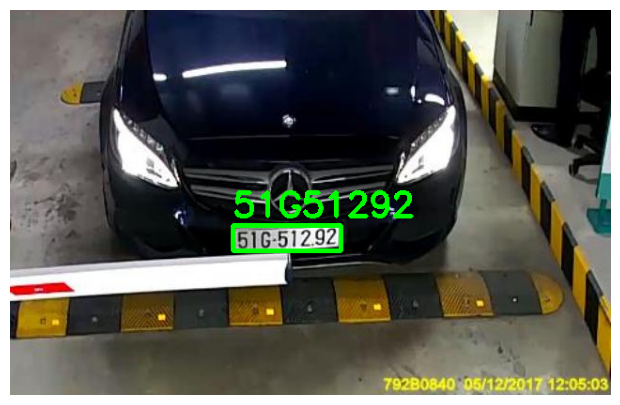

Ảnh: img_002474.jpg | Nhận diện biển (BSV): 59S131386


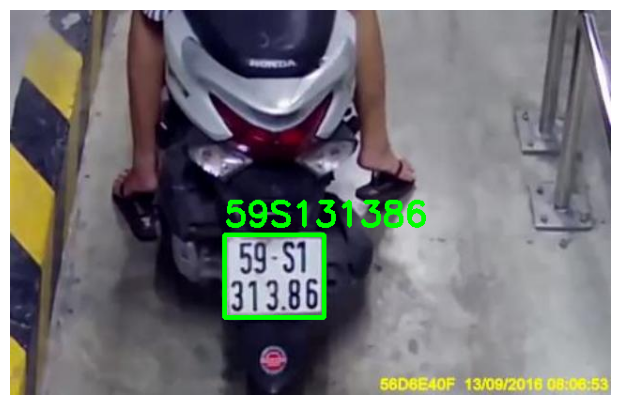

Ảnh: img_002631.jpg | Nhận diện biển (BSV): 59M190977


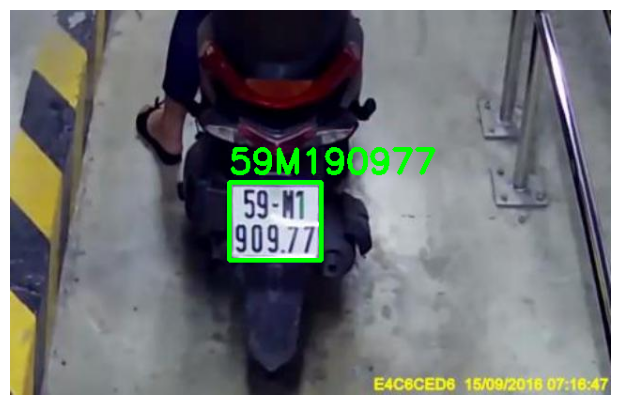

In [21]:
import cv2
import os
import glob
import random
import matplotlib.pyplot as plt
import yaml
from ultralytics import YOLO

# Tải mô hình tốt nhất
with open('/content/dataset_ocr/data.yaml', 'r') as f:
    ocr_cfg = yaml.safe_load(f)
OCR_CLASSES = ocr_cfg['names']

best_detect = YOLO('/content/drive/MyDrive/DoAnTGMT/runs/detect_plate_exp2/weights/best.pt')
best_ocr = YOLO('/content/drive/MyDrive/DoAnTGMT/runs/ocr_characters_exp2/weights/best.pt')

def predict_license_plate(image_path):
    img = cv2.imread(image_path)
    res_detect = best_detect.predict(image_path, conf=0.4, verbose=False)[0]
    plates = []

    for box in res_detect.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cls_detect = int(box.cls[0])
        p_type = 'BSD' if cls_detect == 0 else 'BSV'

        crop = img[y1:y2, x1:x2]
        if crop.size == 0: continue

        res_ocr = best_ocr.predict(crop, conf=0.3, verbose=False)[0]

        char_boxes, char_classes = [], []
        for c_box in res_ocr.boxes:
            cx1, cy1, cx2, cy2 = map(int, c_box.xyxy[0])
            c_cls = int(c_box.cls[0])
            char_boxes.append((cx1, cy1, cx2, cy2))
            char_classes.append(OCR_CLASSES[c_cls])

        plate_text = ""
        if len(char_boxes) > 0:
            items = list(zip(char_boxes, char_classes))
            if p_type == 'BSD':
                items.sort(key=lambda x: x[0][0])
                plate_text = "".join([x[1] for x in items])
            else:
                y_centers = [(b[1] + b[3]) / 2 for b, _ in items]
                y_mean = sum(y_centers) / len(y_centers)

                line1 = [x for x in items if (x[0][1] + x[0][3])/2 < y_mean]
                line2 = [x for x in items if (x[0][1] + x[0][3])/2 >= y_mean]

                line1.sort(key=lambda x: x[0][0])
                line2.sort(key=lambda x: x[0][0])
                plate_text = "".join([x[1] for x in line1]) + "".join([x[1] for x in line2])

        plates.append({'bbox': (x1, y1, x2, y2), 'type': p_type, 'text': plate_text})
    return img, plates

# Chạy thử 3 ảnh và hiển thị kết quả
test_imgs = glob.glob('/content/final_dataset_detect/test/images/*')
sample_imgs = random.sample(test_imgs, min(3, len(test_imgs)))

for img_path in sample_imgs:
    img, plates = predict_license_plate(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 5))
    for p in plates:
        x1, y1, x2, y2 = p['bbox']
        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 4)
        cv2.putText(img_rgb, p['text'], (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3)
        print(f"Ảnh: {os.path.basename(img_path)} | Nhận diện biển ({p['type']}): {p['text']}")

    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()
